# AushadhiNet: Graph Neural Network for Cardiovascular Drug-Drug Interaction Prediction

**Research Project | Hack4Health: Byte2Beat Hackathon 2026 (Devpost)**  
**Author:** Adya Prasad  
**Domain:** Drug (Medicines) Safety | Cardiovascular Polypharmacy | Graph Machine Learning

This notebook implements **AushadhiNet**, a Graph Attention Network (GATv2) architecture **_from scratch_** _(after research_) for predicting adverse drug-drug interactions (DDIs) in cardiovascular disease (CVD) patients that also works for common treatments. The system addresses a critical clinical challenge: **polypharmacy-induced adverse events (side effects between cardiac drugs)** for example **Beta Blockers + Antidepressants** and patients managing multiple comorbidities (hypertension, diabetes, hyperlipidemia).

Unlike traditional rule-based DDI databases, AushadhiNet learns **molecular-level interaction patterns** from chemical structures, I tried enabling model to predict interactions for novel drug combinations not present in training data, a capability crucial for emerging cardiovascular therapeutics.

### PROBLEM STATEMENT

### Clinical Context
Cardiovascular patients typically receive 4-8 concurrent medications (beta-blockers, antidepressants ACE inhibitors, statins, anticoagulants, antidiabetics), creating a complex polypharmacy landscape. The combinatorial explosion of possible drug pairs (>45 combinations for 10 drugs) makes manual safety assessment infeasible.

### Research Gap
Existing DDI prediction systems suffer from:
1. **Limited coverage**: Only 2-5% of possible drug pairs have documented interactions
2. **Rule-based rigidity**: Cannot generalize to new drugs or unseen combinations
3. **Lack of molecular insight**: Fail to capture chemical compatibility patterns
4. **Binary predictions**: Miss interaction severity and mechanism classification


## Proposed Solution: AushadhiNet Architecture
> A Multi-View Graph Neural Network Model

**AushadhiNet** models the drug interaction problem as **link prediction on a molecular graph**:
- **Nodes**: Drugs (1,706 cardiovascular medications from DrugBank)
- **Edges**: Known interactions (191,808 documented DDI pairs)
- **Node Features**: Multi-view molecular representations capturing complementary chemical properties
- **Task**: Predict probability and type of interaction for any drug pair

### Pipeline summary

| Aspect | Flow |
|--------|----------------|
| **Data** | DrugBank DDI + SMILES; multi-view (Morgan, MACCS, phys-chem); stratified 70/15/15 train/val/test. |
| **Model** | Multi-view attention → GATv2 (config layers) → edge classifier (binary + type); fits subgraph-based, memory-efficient training. |
| **Training** | Priority 1: Full-graph GNN once/epoch + edge-only batches (no k_hop per batch). AMP, graph on GPU, validate every N epochs, optional torch.compile. |
| **Metrics** | Validation: loss, accuracy, F1, precision, recall; test: same + ROC-AUC. |

#### There is **four** different combination of training (for better generalization and regularization):
1. Without Data Augmentation and Focal loss
2. With Data Augmentation and no focal loss
3. Without Data Augmentation but with focal loss
4. With both Data Augmentation and Focal loss

### Model Behavior (Prediction Working)
- On giving 'pair of drug' model gives:
    - _Binary Result:=_                  1 (Interaction) OR 0 (No-Interaction)
    - _Interaction Probability:=_     XX.XX% (percentage) [How much model is confidence on its binary result]
    - _Predicted 'Interaction Type'=_   XX (drugbank DDO type: number)
    - _Interaction Type Confidence:=_  XX.XX% (percentage) [How much model is confidence on interaction type]

> #### Checkout the handy and mobile streamlit app using this model

### 1. Importing Libraries and Dependencies

In [19]:
# Utilities
import gc
import time
import json
import os
from datetime import timedelta, datetime
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython import display
import seaborn as sns
import networkx as nx

# Deep learning frameworks
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch_geometric.nn import GATv2Conv, GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import k_hop_subgraph
from torch.amp import GradScaler, autocast

# ML preprocessing and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score, precision_recall_curve, auc, confusion_matrix
from safetensors.torch import save_model as save_safetensors, load_model as load_safetensors

# Molecular processing
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors, MACCSkeys


### 2. Memory optimization and Directories Validation

In [2]:
# Runtime Optimization
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"● DEVICE: {DEVICE}")
DEVICE_TYPE = DEVICE.type
# Aggressive memory management
if DEVICE_TYPE == 'cuda':
    torch.cuda.empty_cache()
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    # Force garbage collection
    gc.collect()
    print(f"- GPU: {torch.cuda.get_device_name(0)}")
    print(f"- GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print("- ✓ Memory optimization enabled")

# Clear CUDA Cache
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    # Set Allocator Strategy to reduce fragmentation
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
    print(f"- GPU Memory Freed. Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
    print(f"- Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")
else:
    print("-Running on CPU (No CUDA clear needed)")

TIMESTAMP = datetime.now().strftime("%d_%b_%H-%M")

# validating artifact directories:
required_directories = ['images', 'models']
for folder in required_directories:
    if not os.path.exists(folder):
        print(f"✘ Directory `{folder}/` not found \nCreating...")
        os.makedirs(folder)
    else:
        print(f"✓ Directory `{folder}/` exists")

● DEVICE: cuda
- GPU: NVIDIA GeForce GTX 1650
- GPU Memory: 4.00 GB
- ✓ Memory optimization enabled
- GPU Memory Freed. Allocated: 0.00 MB
- Reserved: 0.00 MB
✓ Directory `images/` exists
✓ Directory `models/` exists


### 2.2 Path Configurations

In [3]:
DDIS_DATA_PATH = 'dataset/drugdata/ddis.csv'
DRUG_SMILE_DATA_PATH = 'dataset/drugdata/drug_smiles.csv'
DDI_TYPE_MAP = 'dataset/drugdata/ddi_type_mapping.json'
# DDIS_DATA_PATH = 'https://raw.githubusercontent.com/Adya-Prasad/AushadhiNet/refs/heads/main/dataset/drugdata/ddis.csv'
# DRUG_SMILE_DATA_PATH = 'https://raw.githubusercontent.com/Adya-Prasad/AushadhiNet/refs/heads/main/dataset/drugdata/drug_smiles.csv'
# DDI_TYPE_MAP = 'dataset/drugdata/ddi_type_mapping.json'
MODEL_WEIGHT_PATH = f"models/AushadiNet_GATv2_{TIMESTAMP}"
MODEL_METADATA_PATH = f"models/AushadiNet_GATv2-metadata_{TIMESTAMP}"

### 3. Parameters Configurations
Defines the complete hyperparameter space through a centralized configuration dictionary.The architecture parameters `hidden_dim=384`, `_heads=6`, `n_gat_layers=3` specify a moderately deep Graph Attention Network with multi-head attention mechanisms.
 The training dynamics are controlled through `learning rate (lr=3e-4)`, `weight decay (5e-5)`, and `dropout (0.25)` parameters, balancing model capacity with regularization.

The gradient accumulation strategy `physical_batch_size=512`, `accumulation_steps=4` implements a memory-efficient training paradigm. The focal loss configuration (focal_alpha=0.7, focal_gamma=2.0) addresses class imbalance by down-weighting.

Effective Batch Size Formula: $Effective Batch=Physical Batch×Accumulation Steps$

In [4]:
CONFIG = {
    # Model capacity
    "physical_batch_size": 512,
    "accumulation_steps": 4,
    "hidden_dim": 384,           
    "n_heads": 6,               
    "dropout": 0.25,         
    "n_gat_layers": 3,           
    
    # Better training dynamics
    "lr": 3e-4,                  # Lower LR for fine-tuning
    "weight_decay": 5e-5,        # Reduced regularization
    # "epochs": 200,               # 200 epoch is a good fit
    "epochs": 20,
    
    # Loss configuration
    "type_loss_weight": 0.3,     # Reduced (focus on binary first)
    "use_focal_loss": True,      # Use focal loss for hard examples
    "use_class_weights": False,
    "focal_alpha": 0.7,          # Weight for positive class
    "focal_gamma": 2.0,          # Focus on hard examples
    
    # Scheduler
    "scheduler_patience": 7,     # More patience
    "scheduler_factor": 0.5,
    "min_lr": 1e-6,
    
    # System
    "full_graph_on_gpu": True,
    "validate_every_n_epochs": 3,
    "device_platform": "Local",
    
    # Data augmentation
    "use_data_aug": True,
    "edge_dropout_rate": 0.05,   # Reduced
    "feature_noise": 0.005,      # Reduced
}


### 4. Data Loading and Sanity Checks
a. Quantifying the overlap between drugs with known interactions and those with available molecular structures.

b. Comprehensive data quality assessment, identifying null values, distribution skewness, and structural anomalies. Crucial for detecting data corruption, missing values, or encoding errors before expensive model training begins.

Coverage Metric: $\text{Coverage} = \frac{|\text{DDI Drugs} \cap \text{SMILES Drugs}|}{|\text{DDI Drugs}|} \times 100\%$


In [5]:
# Load DDI data
def read_data(ddi_path: str = DDIS_DATA_PATH, smiles_path: str = DRUG_SMILE_DATA_PATH):
    """Load raw DDI and SMILES tables from disk."""
    ddi_df = pd.read_csv(ddi_path)
    smiles_df = pd.read_csv(smiles_path)
    print("✓ Data loaded successfully")
    print("● DDI shape:", ddi_df.shape)
    unique_drugs_ddi = set(ddi_df['d1'].unique()) | set(ddi_df['d2'].unique())
    print(f"• Total DDI pairs: {len(ddi_df)}")
    print(f"• Unique drugs in DDI: {len(unique_drugs_ddi)}")
    print(f"• Drugs with SMILES: {len(smiles_df)}")
    print(f"• Drug Pair Interaction type 0: {(ddi_df['type'] == 0).sum()}")
    print(f"• Drug Pair Interaction type 7: {(ddi_df['type'] == 7).sum()}")
    print("● SMILES shape:", smiles_df.shape)
    print("● DDI columns:", ddi_df.columns.tolist())
    print("● SMILES columns:", smiles_df.columns.tolist())
    drugs_with_smiles = set(smiles_df['drug_id'].unique())
    overlap = unique_drugs_ddi & drugs_with_smiles
    print(f"• Drugs with both DDI and SMILES: {len(overlap)}")
    print(f"• Coverage: {len(overlap)/len(unique_drugs_ddi)*100:.2f}%")

    return ddi_df, smiles_df

def quick_sanity_report(ddi_df: pd.DataFrame, smiles_df: pd.DataFrame):
    """Print a compact sanity report (non‑destructive)."""
    print("\nⓘ QUICK SANITY REPORT:\n")

    # DDI
    print("[1. DDI Data: Interaction pairs]")
    print("● Total rows:", len(ddi_df))
    print("● nulls per column:", ddi_df.isnull().sum().to_dict())
    if {"d1", "d2", "type"}.issubset(ddi_df.columns):
        print("● Total interactions types:", ddi_df["type"].nunique())
        print("● Top `type` distribution (top 10):")
        print(ddi_df["type"].value_counts().head(10))

    # SMILES
    print("\n[2. SMILES Data: Molecular Structures]")
    print("● Total rows:", len(smiles_df))
    print("● Checking nulls per column?:", smiles_df.isnull().sum().to_dict())

    # Overlap
    ddi_drugs = set(ddi_df["d1"]).union(set(ddi_df["d2"]))
    smiles_drugs = set(smiles_df["drug_id"]) if "drug_id" in smiles_df.columns else set()
    overlap = ddi_drugs & smiles_drugs
    print(f"\n● Overlap: {len(overlap)}/{len(ddi_drugs)} DDI drugs have SMILES ({100*len(overlap)/len(ddi_drugs):.2f}%)")


# Load 
ddi_df, smiles_df = read_data()
quick_sanity_report(ddi_df, smiles_df)

✓ Data loaded successfully
● DDI shape: (191808, 4)
• Total DDI pairs: 191808
• Unique drugs in DDI: 1706
• Drugs with SMILES: 1706
• Drug Pair Interaction type 0: 11
• Drug Pair Interaction type 7: 244
● SMILES shape: (1706, 2)
● DDI columns: ['d1', 'd2', 'type', 'Neg samples']
● SMILES columns: ['drug_id', 'smiles']
• Drugs with both DDI and SMILES: 1706
• Coverage: 100.00%

ⓘ QUICK SANITY REPORT:

[1. DDI Data: Interaction pairs]
● Total rows: 191808
● nulls per column: {'d1': 0, 'd2': 0, 'type': 0, 'Neg samples': 0}
● Total interactions types: 86
● Top `type` distribution (top 10):
type
48    60751
46    34360
72    23779
74     9470
59     8397
69     7786
19     6140
15     5413
3      5011
5      3160
Name: count, dtype: int64

[2. SMILES Data: Molecular Structures]
● Total rows: 1706
● Checking nulls per column?: {'drug_id': 0, 'smiles': 0}

● Overlap: 1706/1706 DDI drugs have SMILES (100.00%)


### 5. Multi-View Feature Extraction

Why Multiview? Different views capture different aspects:
1. View 1 (Morgan FP): Captures local substructural patterns through circular fingerprinting with radius 2, encoding atom neighborhoods.
2. View 2 (MACCS Keys): Represents predefined pharmacophoric features and functional groups (OH, COOH, etc.)
3. View 3 (Properties): Quantifies global molecular characteristics including molecular weight, lipophilicity (LogP), hydrogen bonding capacity, and topological polar surface area (TPSA).

#### **Deep Dive: Morgan Fingerprints**
Imagine walking from each atom:
- Start at atom A
- Walk 2 steps in all directions
- Record what you see: "carbon-nitrogen-oxygen pattern"
- Hash this pattern → 1 bit in 1024-bit vector
- Repeat for all atoms
- Each atom's local environment within radius $r$ is hashed into a binary vector: 
$FP(m,r)={h(env(a,r)):a∈atoms(m)}$ where $h$ is a hash function and $\text{env}(a, r)$ represents the substructure within $r$ bonds of atom $a$.

> Result: Binary vector capturing local substructures

Why`radius=2?`
- Radius 1: Too local (just immediate bonds)
- Radius 2: Good balance (captures small functional groups)
- Radius 3: Too broad (high memory, diminishing returns)

Why `fpSize=1024?`
- Smaller (512): More collisions (different patterns → same bit)
- 1024: Good balance
- Larger (2048): Sparse, high memory

What are `MACCS Keys?` Predefined 166 structural patterns (keys):
- Key 1: "Has O atom?"
- Key 50: "Has aromatic ring?"
- Key 120: "Has carboxylic acid group?"

In [6]:
class DrugFeatureExtractor:
    """
    Extracting diverse 'multiviews' of the same molecule.
    View 1: Morgan FP (Detailed Substructure)
    View 2: MACCS Keys (Functional Groups)
    View 3: Physico-Chemical Properties (Global Properties)
    """
    def __init__(self):
        self.morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
        
    def get_features(self, smiles_df):
        view1_morgan = []
        view2_maccs = []
        view3_phys = []
        valid_ids = []
        
        print("● Extracting Multi-View Features...")
        
        for _, row in smiles_df.iterrows():
            mol = Chem.MolFromSmiles(str(row["smiles"]))
            if mol:
                # View 1: Morgan Fingerprint (1024 dim)
                fp = np.array(self.morgan_gen.GetFingerprint(mol), dtype=np.float32)
                
                # View 2: MACCS Keys (167 dim) - Great for functional groups
                maccs = np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)
                
                # View 3: Physico-chemical 8 properties (8 dim) - Great for transport/metabolism
                desc = np.array([
                    Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
                    Descriptors.NumHDonors(mol), Descriptors.NumHAcceptors(mol),
                    Descriptors.TPSA(mol), Descriptors.NumRotatableBonds(mol),
                    Descriptors.NumAromaticRings(mol), Descriptors.FractionCSP3(mol)
                ], dtype=np.float32)
                
                view1_morgan.append(fp)
                view2_maccs.append(maccs)
                view3_phys.append(desc)
                valid_ids.append(row["drug_id"])
        
        # Stack and Normalize View 3 (since it has large values like Weight)
        v1 = np.stack(view1_morgan)
        v2 = np.stack(view2_maccs)
        v3 = np.stack(view3_phys)
        
        scaler = StandardScaler()
        v3 = scaler.fit_transform(v3)
        
        print(f"✓ Processed {len(valid_ids)} drugs.")
        print(f"  - View 1 Shape: {v1.shape}")
        print(f"  - View 2 Shape: {v2.shape}")
        print(f"  - View 3 Shape: {v3.shape}")
        
        return {
            "v1": torch.tensor(v1, dtype=torch.float),
            "v2": torch.tensor(v2, dtype=torch.float),
            "v3": torch.tensor(v3, dtype=torch.float),
            "ids": valid_ids
        }

# Load and Process
smiles_df = pd.read_csv(DRUG_SMILE_DATA_PATH)
extractor = DrugFeatureExtractor()
features_dict = extractor.get_features(smiles_df)

● Extracting Multi-View Features...
✓ Processed 1706 drugs.
  - View 1 Shape: (1706, 1024)
  - View 2 Shape: (1706, 167)
  - View 3 Shape: (1706, 8)


### 6. Graph Construction and Stratified Data Splitting
The `raphBuilder` class transforms tabular DDI data into a graph-structured representation suitable for geometric deep learning. The `build()` method constructs a bidirectional edge index (since drug interactions are symmetric: if A interacts with B, then B interacts with A), encodes interaction types via `LabelEncoder`, and integrates negative samples to create a balanced learning signal.

The `create_stratified_split()` method implements a 70/15/15 train/validation/test partition with stratification on binary labels, ensuring proportional representation of positive and negative interactions across splits. This prevents distribution shift between training and evaluation sets. A critical consideration given the class imbalance inherent in DDI datasets (most drug pairs do not interact).


In [ ]:
class GraphBuilder:
    def __init__(self, ddi_path, feature_dict):
        self.ddi_df = pd.read_csv(ddi_path)
        self.feats = feature_dict
        self.drug_map = {d: i for i, d in enumerate(feature_dict['ids'])}
        self.idx_map = {i: d for d, i in self.drug_map.items()}
        self.type_enc = LabelEncoder()
        
    def build(self):
        # Map Edges
        pos_src, pos_dst, pos_types = [], [], []
        neg_src, neg_dst = [], []
        
        print("● Building DDI Graph Topology...")
        for _, row in self.ddi_df.iterrows():
            if row['d1'] in self.drug_map and row['d2'] in self.drug_map:
                u, v = self.drug_map[row['d1']], self.drug_map[row['d2']]
                
                # Bidirectional Positive Edge
                # Because If A interacts with B, then B interacts with A
                pos_src.extend([u, v])
                pos_dst.extend([v, u])
                pos_types.extend([row['type'], row['type']])
                
                # Negative Edge Handling: "DRUGID$t" or "DRUGID$h" -> extract DRUGID only
                if isinstance(row['Neg samples'], str):
                    neg_raw = row['Neg samples'].strip().split('$')[0]
                    if neg_raw and neg_raw in self.drug_map:
                        w = self.drug_map[neg_raw]
                        neg_src.extend([u, w])
                        neg_dst.extend([w, u])

        # Convert to Tensors
        pos_edge_index = torch.tensor([pos_src, pos_dst], dtype=torch.long)
        neg_edge_index = torch.tensor([neg_src, neg_dst], dtype=torch.long)
        
        # Combine for processing
        full_edge_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
        
        # Label Encoding: Encode Types
        y_types_enc = self.type_enc.fit_transform(pos_types)
        
        # Create Labels
        # Binary: 1 for pos, 0 for neg
        y_binary = torch.cat([torch.ones(pos_edge_index.shape[1]), torch.zeros(neg_edge_index.shape[1])]).long()
        # Type: Encoded for pos, -1 for neg
        y_type = torch.cat([torch.tensor(y_types_enc), torch.full((neg_edge_index.shape[1],), -1)]).long()
        
        return {
            "x_v1": self.feats['v1'],
            "x_v2": self.feats['v2'],
            "x_v3": self.feats['v3'],
            "edge_index": full_edge_index,
            "y_binary": y_binary,
            "y_type": y_type,
            "n_types": len(self.type_enc.classes_),
            "encoder": self.type_enc,
            "drug_map": self.drug_map
        }

    def create_stratified_split(self, graph):
        # Stratified Split based on Binary Labels to ensure Negatives are balanced in Train/Val
        print("● Creating Stratified Splits (TDCommons Standard)...")
        n_edges = graph['edge_index'].shape[1]
        indices = np.arange(n_edges)
        
        train_idx, temp_idx = train_test_split(
            indices, test_size=0.3, stratify=graph['y_binary'], random_state=42
        )
        val_idx, test_idx = train_test_split(
            temp_idx, test_size=0.5, stratify=graph['y_binary'][temp_idx], random_state=42
        )
        
        # Create Boolean Masks
        for name, idx in zip(['train', 'val', 'test'], [train_idx, val_idx, test_idx]):
            mask = torch.zeros(n_edges, dtype=torch.bool)
            mask[idx] = True
            graph[f'{name}_mask'] = mask
            
        print(f"  - Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
        return graph

builder = GraphBuilder(DDIS_DATA_PATH, features_dict)
graph_data = builder.build()
graph = builder.create_stratified_split(graph_data)

● Building DDI Graph Topology...
● Creating Stratified Splits (TDCommons Standard)...
  - Train: 537062 | Val: 115085 | Test: 115085


### 7. Data Augmentation
_Stochastic Regularization via Graph Perturbation_. `DDIDataAugmenter`** class implements two complementary augmentation techniques to improve model generalization. **Edge dropout** randomly masks a fraction of edges during training, forcing the model to learn robust representations that don't rely on specific connectivity patterns. **Feature perturbation** adds Gaussian noise to node features, simulating measurement uncertainty and molecular conformational variability.

These augmentation strategies act as implicit regularizers, expanding the effective training set size without collecting additional data. The stochastic nature of augmentation prevents overfitting to specific graph structures, particularly important given the relatively small size of curated DDI datasets compared to the vast chemical space.

Augmented Features: $X_{aug} = X+ \sigma \cdot ϵ$ , $ϵ∼N(0, I)$ where $\sigma$ is controlled by `feature_noise` parameter. $\epsilon$ is random noise draws samples from a Standard Normal Distribution (mean = 0, variance = 1) It is  generated by `torch.randn_like` and this noise is multiplied by the `feature_noise` parameter ($\sigma$).

`graph['x_v1']`, `graph['x_v2']`, and `graph['x_v3']` represent multi-view Features of the drugs. Instead of using just one way to describe a molecule, the model uses three different "views":

In [8]:
class DDIDataAugmenter:
    """
    Augment training data to improve generalization:
    1. Edge dropout (random edge masking)
    2. Feature perturbation
    3. Hard negative mining
    """    
    @staticmethod
    def augment_graph_training(graph, edge_dropout=0.1, feature_noise=0.01):
        """
        Apply augmentation during training epoch.
        """
        # Edge dropout: Randomly remove edges from adjacency
        if edge_dropout > 0:
            mask = torch.rand(graph['edge_index'].shape[1]) > edge_dropout
            aug_edge_index = graph['edge_index'][:, mask]
        else:
            aug_edge_index = graph['edge_index']
        # Feature noise: Add small Gaussian noise
        if feature_noise > 0:
            aug_x_v1 = graph['x_v1'] + torch.randn_like(graph['x_v1']) * feature_noise
            aug_x_v2 = graph['x_v2'] + torch.randn_like(graph['x_v2']) * feature_noise
            aug_x_v3 = graph['x_v3'] + torch.randn_like(graph['x_v3']) * feature_noise
        else:
            aug_x_v1, aug_x_v2, aug_x_v3 = graph['x_v1'], graph['x_v2'], graph['x_v3']
        
        return {
            'edge_index': aug_edge_index,
            'x_v1': aug_x_v1,
            'x_v2': aug_x_v2,
            'x_v3': aug_x_v3
        }

## 8. GATv2 Neural Network Architecture
The `GATv2NN class` implements a sophisticated graph neural network architecture combining multi-view fusion with hierarchical message passing. The architecture proceeds through four stages: **(1) View Projection** - three parallel MLPs transform heterogeneous molecular representations into a unified 384-dimensional space with BatchNorm and ReLU activations; **(2) Attention Fusion** - a learned attention mechanism weights the importance of each view; **(3) Graph Convolution** - three stacked GATv2 layers with residual connections perform neighborhood aggregation; **(4) Edge Classification** - a deep MLP predicts interaction probability and type from concatenated node embeddings.

The residual connections $h_{l+1} = \text{GATv2}(h_l) + h_l$ address the vanishing gradient problem in deep networks, enabling stable training of the 3-layer architecture. LayerNorm after each GAT layer stabilizes activations, while dropout provides regularization. The edge classifier's two-head design enables multi-task learning, jointly optimizing binary interaction prediction and interaction type classification.

GATv2 Attention Mechanism: Calculates the attention coefficient ($a_{ij}$), which determines how much importance node $i$ should place on node $j$'s features. $$\alpha_{ij} = \frac{\exp\left(\mathbf{a}^T \text{LeakyReLU}\left(\mathbf{W}[\mathbf{h}_i \Vert \mathbf{h}_j]\right)\right)}{\sum_{k \in \mathcal{N}(i)} \exp\left(\mathbf{a}^T \text{LeakyReLU}\left(\mathbf{W}[\mathbf{h}_i \Vert \mathbf{h}_k]\right)\right)}$$

Multi-Head Aggregation: Shows how the model concatenates ($||$) the outputs of $K$ independent attention "heads" to produce the final node representation.
$$\mathbf{h}'_i = \Vert_{k=1}^K \sigma \left( \sum_{j \in \mathcal{N}(i)} \alpha_{ij}^k \mathbf{W}^k \mathbf{h}_j \right)$$


Architecture Overview:
```
Input: 3 Views (Morgan, MACCS, Properties)
  ↓
[Projection Layers] → All views to same dimension
  ↓
[Attention Fusion] → Learn which view is most important
  ↓
[GAT Layer 1] → Message passing (6 heads, concatenated)
  ↓
[GAT Layer 2] → Message passing (1 head)
  ↓
[GAT Layer 3] → Message passing (1 head)
  ↓
[Edge Classifier] → Predict interaction from node pairs
  ↓
Output: [Binary: interact?, Type: which type?]
```

In [ ]:
class FeatureAttentionLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.atten = nn.Linear(dim, 1)
        
    def forward(self, v1, v2, v3):
        stack = torch.stack([v1, v2, v3], dim=1)
        scores = F.softmax(self.atten(stack), dim=1)
        fused = torch.sum(stack * scores, dim=1)
        return fused, scores

class GATv2NN(nn.Module):
    """
    Improvements:
    1. Residual connections for better gradient flow
    2. Layer normalization for training stability
    3. Edge dropout for regularization
    4. Optional feature masking
    """
    def __init__(self, dims, hidden_dim, n_heads, n_types, dropout=0.3):
        super().__init__()
        
        # View Projectors with BatchNorm
        self.proj_v1 = nn.Sequential(
            nn.Linear(dims['v1'], hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )
        self.proj_v2 = nn.Sequential(
            nn.Linear(dims['v2'], hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )
        self.proj_v3 = nn.Sequential(
            nn.Linear(dims['v3'], hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )
        
        # Feature Attention
        self.feat_attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 4),
            nn.ReLU(),
            nn.Linear(hidden_dim // 4, 1)
        )
        
        # GATv2 Layers with residual connections
        self.gat1 = GATv2Conv(
            hidden_dim, hidden_dim // n_heads, 
            heads=n_heads, concat=True, dropout=dropout
        )
        self.norm1 = nn.LayerNorm(hidden_dim)
        
        self.gat2 = GATv2Conv(
            hidden_dim, hidden_dim, 
            heads=1, concat=False, dropout=dropout
        )
        self.norm2 = nn.LayerNorm(hidden_dim)

        self.gat3  = GATv2Conv(
            hidden_dim, hidden_dim,
            heads=1, concat=False, dropout=dropout
        ) 
        self.norm3 = nn.LayerNorm(hidden_dim)
        
        # Edge Classifier with deeper network
        self.edge_encoder = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
        )
        
        self.head_bin = nn.Linear(hidden_dim // 2, 2)
        self.head_type = nn.Linear(hidden_dim // 2, n_types)
        
        self.dropout = dropout

        print("Model Intialized\n")

    def get_node_embeddings(self, x_v1, x_v2, x_v3, edge_index):
        """
        Full-graph forward with residual connections and normalization.
        """
        # Project each view
        h1 = self.proj_v1(x_v1)
        h2 = self.proj_v2(x_v2)
        h3 = self.proj_v3(x_v3)
        
        # Multi-view attention fusion
        stack = torch.stack([h1, h2, h3], dim=1)  # (N, 3, hidden_dim)
        scores = F.softmax(self.feat_attention(stack), dim=1)
        h_fused = torch.sum(stack * scores, dim=1)
        
        # GAT Layer 1 with residual
        h_gat1 = self.gat1(h_fused, edge_index)
        h_gat1 = self.norm1(h_gat1 + h_fused)  # Residual connection
        h_gat1 = F.elu(h_gat1)
        
        # GAT Layer 2 with residual
        h_gat2 = self.gat2(h_gat1, edge_index)
        node_emb = self.norm2(h_gat2 + h_fused)  # Skip connection to fusion

        # GAT Layer 3 with residual
        h_gat3 = self.gat3(node_emb, edge_index)
        node_emb = self.norm3(h_gat3 + h_fused)
        
        return node_emb

        # : Remove edge dropout for now
    def forward_edges_from_emb(self, node_emb, edge_label_index):
        src, dst = edge_label_index[0], edge_label_index[1]
        # edge operator
        edge_feat = torch.cat([node_emb[src], node_emb[dst]], dim=-1)
        shared = self.edge_encoder(edge_feat)  # or self.classifier if using original model
        return self.head_bin(shared), self.head_type(shared)

    def forward(self, x_v1, x_v2, x_v3, edge_index, edge_label_index):
        """Full forward pass (for inference)."""
        node_emb = self.get_node_embeddings(x_v1, x_v2, x_v3, edge_index)
        return self.forward_edges_from_emb(node_emb, edge_label_index) 

### 9. Focal Loss Implementation
_Class Imbalance Mitigation via Hard Example Mining_. The FocalLoss class implements the focal loss objective function, designed to address severe class imbalance by down-weighting easy examples and focusing training on hard-to-classify instances. The loss modulates standard cross-entropy with a modulating factor $(1 - p_t)^\gamma$, where $p_t$ is the model's estimated probability for the true class and $\gamma$ controls the focusing strength.

Focal Loss Formula: $FL(p_t)=−α_t(1−p_t)^γlog(p_t)$

In [10]:
# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.7, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()

### 10. Best Model Tracking 
_Intelligent Checkpoint Management with Delta Thresholding_. A sophisticated model persistence strategy that balances storage efficiency with performance optimization. Unlike naive approaches that save every improvement, this tracker employs a minimum delta threshold (`min_delta=0.005`), filtering out noise-driven fluctuations and saving only statistically significant improvements. The automatic deletion of superseded checkpoints prevents disk bloat while maintaining the single best model.

**Improvement Criterion:** Save if: $F1_{current} - F1_{best} > δ_{min}$

In [11]:
class BestModelTracker:
    """
    Smart model saving with 3 rules:
    1. Only save if improvement > min_delta (ignore noise)
    2. Only keep 1 file (delete old best before saving new)
    3. Save in safetensors format
    """
    def __init__(self, save_dir='models', min_delta=0.005, metric_name='f1'):
        self.save_dir = save_dir
        self.min_delta = min_delta     
        self.metric_name = metric_name
        self.best_score = 0.0
        self.best_path = None
        self.save_count = 0
        os.makedirs(save_dir, exist_ok=True)

    def update(self, model, score, epoch):
        """
        Call after each validation.
        Returns True if model was saved, False if improvement was too small.
        """
        improvement = score - self.best_score
        
        if improvement > self.min_delta:
            # Delete old best model file
            if self.best_path and os.path.exists(self.best_path):
                os.remove(self.best_path) # removing old checkpoint          
            # Save new best
            self.best_score = score
            filename = f'AushadiNet_GATv2_ep-{epoch}_{TIMESTAMP}.safetensors'
            self.best_path = os.path.join(self.save_dir, filename)
            
            # Get base model (handles torch.compile wrapper)
            base_model = model._orig_mod if hasattr(model, '_orig_mod') else model
            save_safetensors(base_model, self.best_path)
            
            self.save_count += 1
            print(f"[✓] New best model found! At epoch {epoch} with F1: {score:.4f} and improvement of {improvement:.4f}")
            return True
        
        return False

    def load_best(self, model):
        """Load the best saved model back into model."""
        if self.best_path and os.path.exists(self.best_path):
            base_model = model._orig_mod if hasattr(model, '_orig_mod') else model
            load_safetensors(base_model, self.best_path)
            print(f"(✓) Loaded best model: {os.path.basename(self.best_path)}")
            print(f"   Best {self.metric_name}: {self.best_score:.4f}")
        else:
            print("(✘) No saved model found.")
        return model

    def summary(self):
        print(f"\n➜ Model Saving Summary:")
        print(f"- Total progressive best models: {self.save_count}")
        print(f"- Best {self.metric_name}: {self.best_score:.4f}")
        print(f"- Saved at: {self.best_path}")

## 11. Training Pipeline Implementation
_Dual-Optimizer Strategy with Gradient Accumulation_. The `train_model()` function implements a sophisticated training protocol addressing the unique challenges of graph neural network optimization. The architecture employs two separate optimizers: one for GNN encoder parameters (view projectors, GAT layers) and another for edge classifier parameters. This separation enables differential learning rates and prevents the edge classifier from dominating gradient flow during early training.

The training proceeds in three phases per epoch: **(1) GNN Forward Pass** - compute node embeddings with gradient tracking; **(2) Edge Batch Training** - train edge classifier on mini-batches using detached (but gradient-enabled) node embeddings, accumulating gradients; **(3) GNN Backward Pass** - propagate accumulated edge gradients back through the GNN encoder. This "proxy gradient" technique enables memory-efficient training on large graphs while maintaining end-to-end differentiability.

The validation protocol executes every `validate_every_n_epochs`, computing _accuracy, F1-score, precision_, and _recall_ on the held-out validation set. The `ReduceLROnPlateau` scheduler dynamically adjusts learning rates based on validation F1, implementing a form of adaptive optimization that accelerates convergence.

**Gradient Accumulation Formula:** The accumulated gradient as the average of the gradients calculated over accumulation steps. $$\text{Gradient Accumulation: } \nabla_\theta = \frac{1}{N_{\text{accum}}} \sum_{i=1}^{N_{\text{accum}}} \nabla_\theta L_i$$

**Effective Batch Size Formula:** How the "simulated" batch size is calculated by multiplying your actual hardware batch size by the number of accumulation steps. $$\text{Effective Batch Size: } B_{\text{eff}} = B_{\text{physical}} \times N_{\text{accum}} = 512 \times 4 = 2048$$

In [ ]:
def train_model(graph, config, model, device='cuda'):
    """
    FIXED TRAINING: GNN trains via proxy gradient trick.
    - Edge MLP: trains every accumulation step (fast)
    - GNN encoder: trains once per epoch via accumulated gradients
    """
    physical_batch = config["physical_batch_size"]
    accum_steps = config["accumulation_steps"]
    type_w = config.get("type_loss_weight", 0.5)
    validate_every = config.get("validate_every_n_epochs", 2)

    START_TIME = time.perf_counter()
    print(f"MODEL TRAINING STARTING AT: {time.strftime('%H:%M:%S', time.localtime())}...\n")

    # Data Loaders
    train_edges = graph['edge_index'][:, graph['train_mask']]
    train_labels = torch.stack([
        graph['y_binary'][graph['train_mask']],
        graph['y_type'][graph['train_mask']]
    ], dim=1)
    val_edges = graph['edge_index'][:, graph['val_mask']]
    val_labels = torch.stack([
        graph['y_binary'][graph['val_mask']],
        graph['y_type'][graph['val_mask']]
    ], dim=1)

    train_loader = DataLoader(
        TensorDataset(train_edges.t(), train_labels),
        batch_size=physical_batch, shuffle=True,
        pin_memory=True, num_workers=2, persistent_workers=True
    )
    val_loader = DataLoader(
        TensorDataset(val_edges.t(), val_labels),
        batch_size=physical_batch * 2, shuffle=False,
        pin_memory=True, num_workers=2
    )

    # Loss uses condition
    # Class weights calculation
    y_train_bin = graph['y_binary'][graph['train_mask']].numpy()
    n_pos = int((y_train_bin == 1).sum())
    n_neg = int((y_train_bin == 0).sum())

    # Get loss configuration
    use_focal = config.get("use_focal_loss", False)  # Default: False
    use_weights = config.get("use_class_weights", False)  # Default: False

    # Validate configuration
    if use_focal and use_weights:
        print("⚠︎ Warning: Both focal loss and class weights enabled. Using Focal Loss (takes priority).")
        use_weights = False  # Disable class weights

    # Select loss function
    if use_focal:
        crit_bin = FocalLoss(
            alpha=config.get("focal_alpha", 0.7),
            gamma=config.get("focal_gamma", 2.0)
        )
        print(f"✓ Loss: FocalLoss(alpha={config.get('focal_alpha', 0.7)}, gamma={config.get('focal_gamma', 2.0)})")

    elif use_weights and n_pos > 0 and n_neg > 0:
        w_pos = (n_pos + n_neg) / (2.0 * n_pos)
        w_neg = (n_pos + n_neg) / (2.0 * n_neg)
        class_weights = torch.tensor([w_neg, w_pos], dtype=torch.float32, device=device)
        crit_bin = nn.CrossEntropyLoss(weight=class_weights)
        print(f"✓ Loss: CrossEntropyLoss | Class weights: neg={w_neg:.3f}, pos={w_pos:.3f}")

    else:
        crit_bin = nn.CrossEntropyLoss()
        print("✓ Loss: CrossEntropyLoss (unweighted)")

    crit_type = nn.CrossEntropyLoss(ignore_index=-1)

    # Move graph to GPU
    full_adj = graph['edge_index'].to(device)
    x_v1 = graph['x_v1'].to(device)
    x_v2 = graph['x_v2'].to(device)
    x_v3 = graph['x_v3'].to(device)

    # TWO SEPARATE OPTIMIZERS
    # GNN encoder params vs Edge classifier params
    # ============================================
    gnn_param_names = ['proj_v1', 'proj_v2', 'proj_v3', 'feat_attention', 
                   'gat1', 'gat2', 'gat3', 'norm1', 'norm2', 'norm3']
    edge_param_names = ['edge_encoder', 'head_bin', 'head_type']

    # Get underlying module if torch.compile was used
    base_model = model._orig_mod if hasattr(model, '_orig_mod') else model

    gnn_params = [p for n, p in base_model.named_parameters()
                  if any(n.startswith(x) for x in gnn_param_names)]
    edge_params = [p for n, p in base_model.named_parameters()
                   if any(n.startswith(x) for x in edge_param_names)]

    print(f"- GNN params:  {sum(p.numel() for p in gnn_params):,}")
    print(f"- Edge params: {sum(p.numel() for p in edge_params):,}")

    gnn_optimizer  = Adam(gnn_params,  lr=config['lr'], weight_decay=config.get('weight_decay', 1e-4))
    edge_optimizer = Adam(edge_params, lr=config['lr'], weight_decay=config.get('weight_decay', 1e-4))

    # One scaler handles both, calling backward once for each
    edge_scaler = GradScaler()

    gnn_scheduler = lr_scheduler.ReduceLROnPlateau(
        gnn_optimizer, mode='max',
        patience=config.get('scheduler_patience', 4),
        factor=config.get('scheduler_factor', 0.5)
    )
    edge_scheduler = lr_scheduler.ReduceLROnPlateau(
        edge_optimizer, mode='max',
        patience=config.get('scheduler_patience', 4),
        factor=config.get('scheduler_factor', 0.5)
    )

    history = {
        'train_loss': [], 'val_acc': [], 'val_f1': [],
        'val_precision': [], 'val_recall': [], 'training_duration': []
    }

    print(f"\n{'—'*75}")
    print(f"{'Epoch':<6} | {'Train Loss':<11} | {'Val Acc':<8} | {'Val F1':<8} | {'Val P':<8} | {'Val R':<8} | {'Time':<8}")
    print(f"{'—'*75}")

    best_f1 = 0.0
    
    # Tracking the model improvement by min_delta
    tracker = BestModelTracker(save_dir='models',min_delta=0.005, metric_name='f1')

    for epoch in range(1, config['epochs'] + 1):
        epoch_start = time.time()
        model.train()
            
        # DATA AUGMENTATION: Apply edge dropout and feature noise
        # =======================================================

        # first check if true in config
        use_aug = config.get("use_data_aug", True)

        if use_aug and (config.get('edge_dropout_rate', 0) > 0 or config.get('feature_noise', 0) > 0):
            # Augmentation enabled AND configured
            aug_data = DDIDataAugmenter.augment_graph_training(
                {'edge_index': full_adj, 'x_v1': x_v1, 'x_v2': x_v2, 'x_v3': x_v3},
                edge_dropout=config.get('edge_dropout_rate', 0),
                feature_noise=config.get('feature_noise', 0)
            )
            aug_adj = aug_data['edge_index']
            aug_x_v1 = aug_data['x_v1']
            aug_x_v2 = aug_data['x_v2']
            aug_x_v3 = aug_data['x_v3']
            
        else:
            # Augmentation disabled OR not configured
            aug_adj = full_adj
            aug_x_v1, aug_x_v2, aug_x_v3 = x_v1, x_v2, x_v3

        # PHASE 1: Compute GNN node embeddings WITH gradient tracking
        # ============================================================
        gnn_optimizer.zero_grad()
        with autocast(device.type):            
            node_emb = model.get_node_embeddings(aug_x_v1, aug_x_v2, aug_x_v3, aug_adj)

        # Proxy: detach for memory-efficient batch training,
        # but keep requires_grad=True so we can accumulate edge → node gradients
        node_emb_proxy = node_emb.detach().requires_grad_(True) 

        # PHASE 2: Train Edge MLP using proxy embeddings (fast batches)
        # ============================================================
        edge_optimizer.zero_grad()
        total_loss = 0.0       

        for i, (batch_edges, batch_labels) in enumerate(train_loader):
            batch_edges = batch_edges.t().to(device, non_blocking=True)
            y_bin  = batch_labels[:, 0].to(device, non_blocking=True)
            y_type = batch_labels[:, 1].to(device, non_blocking=True)

            with autocast(device.type):
                pred_bin, pred_type = model.forward_edges_from_emb(node_emb_proxy, batch_edges)
                loss = (crit_bin(pred_bin, y_bin) +
                        type_w * crit_type(pred_type, y_type)) / accum_steps

            edge_scaler.scale(loss).backward()   # Accumulates in node_emb_proxy.grad too
            total_loss += loss.item() * accum_steps

            if (i + 1) % accum_steps == 0:
                edge_scaler.step(edge_optimizer)
                edge_scaler.update()
                edge_optimizer.zero_grad()

        train_loss = total_loss / len(train_loader)
        history['train_loss'].append(train_loss)

        # PHASE 3: Propagate accumulated gradients back through GNN
        # ==========================================================
        if node_emb_proxy.grad is not None:
            # Unscale edge_scaler's scale factor before propagating
            # node_emb_proxy.grad was accumulated under edge_scaler's AMP context,
            # so divide by edge_scaler's scale to get true gradient magnitude
            scale = edge_scaler.get_scale()
            unscaled_grad = node_emb_proxy.grad / scale if scale != 0 else node_emb_proxy.grad
            node_emb.backward(unscaled_grad)
            torch.nn.utils.clip_grad_norm_(gnn_params, max_norm=1.0)
            gnn_optimizer.step() # Direct step, no scaler wrapping needed
        gnn_optimizer.zero_grad()

        # Explicitly release augmented tensors
        # Each epoch, augmentation creates NEW GPU tensors (via torch.randn_like).
        # Without del, they linger in memory until Python's GC decides to collect
        # them, which causes fragmentation and eventual OOM on long runs.
        # We only delete if augmentation was active (i.e. they're distinct objects
        # from x_v1/x_v2/x_v3 — deleting aliases of the originals is a no-op but
        # the guard makes the intent explicit).
        if use_aug:
            del aug_adj, aug_x_v1, aug_x_v2, aug_x_v3

        # Validation
        # ==========
        do_validate = (epoch % validate_every == 0) or (epoch == config['epochs'])

        if do_validate:
            model.eval()
            all_preds, all_trues = [], []

            with torch.no_grad():
                with autocast(device.type):
                    node_emb_val = model.get_node_embeddings(x_v1, x_v2, x_v3, full_adj)
                for batch_edges, batch_labels in val_loader:
                    batch_edges = batch_edges.t().to(device, non_blocking=True)
                    p_bin, _ = model.forward_edges_from_emb(node_emb_val, batch_edges)
                    all_preds.extend(torch.argmax(p_bin, dim=1).cpu().numpy())
                    all_trues.extend(batch_labels[:, 0].numpy())

            all_trues = np.array(all_trues)
            all_preds = np.array(all_preds)

            val_acc  = accuracy_score(all_trues, all_preds)
            val_f1   = f1_score(all_trues, all_preds, zero_division=0)
            val_prec = precision_score(all_trues, all_preds, zero_division=0)
            val_rec  = recall_score(all_trues, all_preds, zero_division=0)

            history['val_acc'].append(val_acc)
            history['val_f1'].append(val_f1)
            history['val_precision'].append(val_prec)
            history['val_recall'].append(val_rec)

            gnn_scheduler.step(val_f1)
            edge_scheduler.step(val_f1)

            tracker.update(model, val_f1, epoch)
            if val_f1 > best_f1:
                best_f1 = val_f1

            epoch_time = time.time() - epoch_start
            print(f"{epoch:>4}   | {train_loss:>9.4f}   | {val_acc:>6.4f}  | {val_f1:>6.4f}  | {val_prec:>6.4f}  | {val_rec:>6.4f}  | {epoch_time:>5.1f}s")
        else:
            for k in ['val_acc', 'val_f1', 'val_precision', 'val_recall']:
                history[k].append(history[k][-1] if history[k] else 0.0)

        torch.cuda.empty_cache()
    
    tracker.summary()
    model = tracker.load_best(model)

    END_TIME = time.perf_counter()
    formatted_time = str(timedelta(seconds=int(END_TIME - START_TIME)))
    history['training_duration'].append(formatted_time)

    print(f"{'—'*75}")
    print(f"(✓) {config['epochs']} Epochs completed in {history['training_duration']} "
          f"at {time.strftime('%H:%M:%S', time.localtime())} with best Val F1: {best_f1:.4f}")

    return model, history, tracker

### 12. Model Initialization and Training Execution Step
Instantiates the GATv2NN model with architecture parameters specified in the CONFIG and then start the training

In [13]:
# Initialize model
model = GATv2NN(
    dims={'v1': 1024, 'v2': 167, 'v3': 8},
    hidden_dim=CONFIG['hidden_dim'],
    n_heads=CONFIG['n_heads'],
    n_types=graph['n_types'],
    dropout=CONFIG['dropout']
).to(DEVICE)

# model = torch.compile(model, mode='reduce-overhead')

# Train with optimized function
trained_model, training_history, tracker = train_model(
    graph, 
    CONFIG, 
    model, 
    device=DEVICE
)

Model Intialized

MODEL TRAINING STARTING AT: 13:54:12...

✓ Loss: FocalLoss(alpha=0.7, gamma=2.0)
- GNN params:  1,392,577
- Edge params: 387,352

———————————————————————————————————————————————————————————————————————————
Epoch  | Train Loss  | Val Acc  | Val F1   | Val P    | Val R    | Time    
———————————————————————————————————————————————————————————————————————————
[✓] New best model found! At epoch 3 with F1: 0.6669 and improvement of 0.6669
   3   |    0.4312   | 0.5005  | 0.6669  | 0.5003  | 1.0000  |  48.5s
   6   |    0.3090   | 0.5003  | 0.6668  | 0.5002  | 1.0000  |  46.1s
   9   |    0.2540   | 0.5000  | 0.6667  | 0.5000  | 1.0000  |  33.9s
  12   |    0.2214   | 0.5021  | 0.6675  | 0.5011  | 0.9996  |  51.7s
[✓] New best model found! At epoch 15 with F1: 0.6735 and improvement of 0.0066
  15   |    0.2009   | 0.5196  | 0.6735  | 0.5101  | 0.9910  |  35.4s
[✓] New best model found! At epoch 18 with F1: 0.6935 and improvement of 0.0199
  18   |    0.1842   | 0.6187  | 0.

### 13. Training Visualization Dashboard
Generates a comprehensive four-panel visualization tracking key performance indicators across validated epochs. **The function intelligently filters out _'non-validated epochs'_ (determined by validate_every_n_epochs)**, preventing misleading flat-line artifacts in metric plots. Each subplot displays a distinct aspect of model behavior: training loss convergence, validation accuracy, F1-score evolution, and precision-recall trade-offs. With annotation of best-performing epochs (marked with red stars).

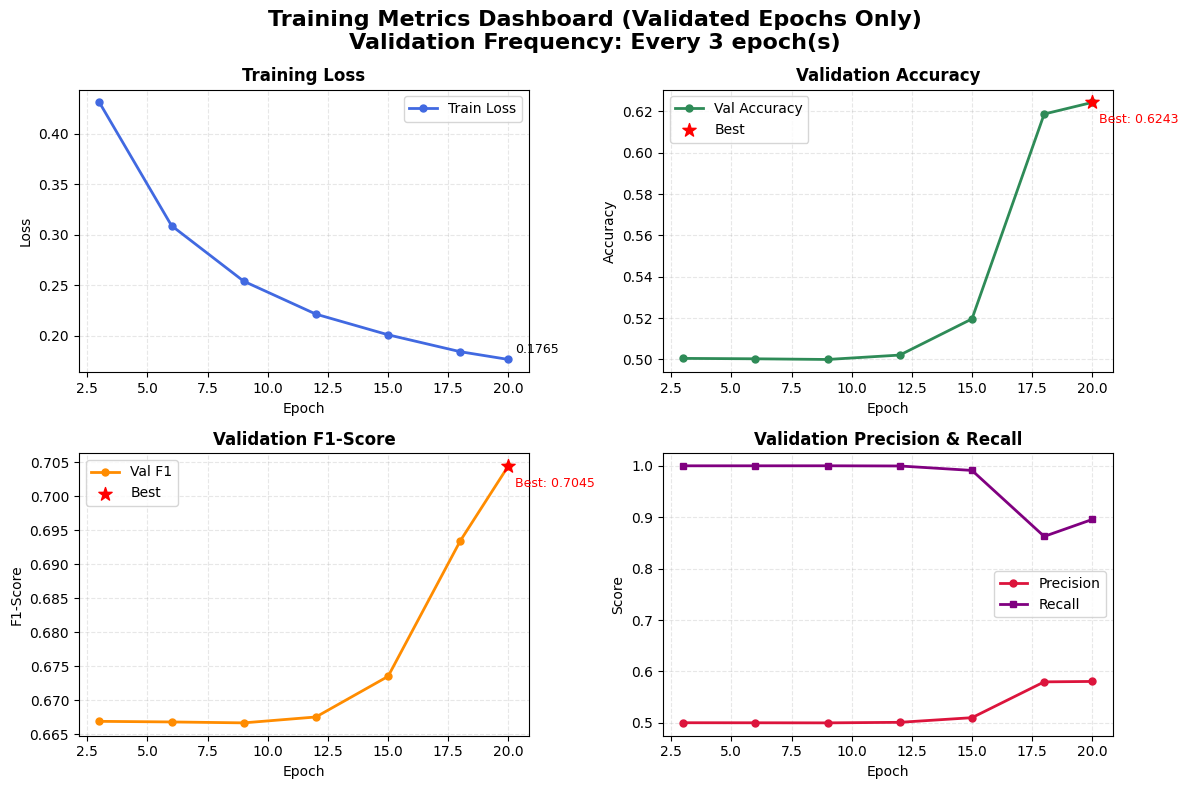

In [14]:
def plot_training_dashboard(history, config):
    """
    Plot training metrics dashboard showing ONLY validated epochs.
    Removes flat lines by filtering out epochs where validation was skipped.
    Parameters:
    - history: Dictionary with training metrics
    - config: Configuration dictionary with validate_every_n_epochs
    """
    display.clear_output(wait=True)
    
    total_epochs = len(history['train_loss'])
    validate_every = config.get('validate_every_n_epochs', 1)
    
    # Determine which epochs had actual validation
    validated_epochs = []
    for epoch in range(1, total_epochs + 1):
        do_validate = (epoch % validate_every == 0) or (epoch == total_epochs)
        if do_validate:
            validated_epochs.append(epoch)
    
    # Extract metrics only for validated epochs
    # Note: epoch indices are 0-based in lists, but 1-based in display
    validated_indices = [e - 1 for e in validated_epochs]  # Convert to 0-based    
    train_loss_validated = [history['train_loss'][i] for i in validated_indices]
    val_acc_validated = [history['val_acc'][i] for i in validated_indices]
    val_f1_validated = [history['val_f1'][i] for i in validated_indices]
    val_precision_validated = [history['val_precision'][i] for i in validated_indices]
    val_recall_validated = [history['val_recall'][i] for i in validated_indices]
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Training Metrics Dashboard (Validated Epochs Only)\nValidation Frequency: Every {validate_every} epoch(s)", 
                 fontsize=16, fontweight='bold')
    # 1 Training Loss
    axes[0, 0].plot(validated_epochs, train_loss_validated, 
                    color='royalblue', marker='o', markersize=5, linewidth=2, label='Train Loss')
    axes[0, 0].set_title("Training Loss", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].grid(alpha=0.3, linestyle='--')
    axes[0, 0].legend()
    
    # Add value annotations for key points
    if len(train_loss_validated) > 0:
        axes[0, 0].annotate(f'{train_loss_validated[-1]:.4f}', 
                           xy=(validated_epochs[-1], train_loss_validated[-1]),
                           xytext=(5, 5), textcoords='offset points', fontsize=9)

    # 2️ Validation Accuracy
    axes[0, 1].plot(validated_epochs, val_acc_validated, 
                    color='seagreen', marker='o', markersize=5, linewidth=2, label='Val Accuracy')
    axes[0, 1].set_title("Validation Accuracy", fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].grid(alpha=0.3, linestyle='--')
    axes[0, 1].legend()
    
    # Add best accuracy marker
    if len(val_acc_validated) > 0:
        best_acc_idx = val_acc_validated.index(max(val_acc_validated))
        axes[0, 1].scatter([validated_epochs[best_acc_idx]], [val_acc_validated[best_acc_idx]], 
                          color='red', s=100, zorder=5, marker='*', label='Best')
        axes[0, 1].annotate(f'Best: {val_acc_validated[best_acc_idx]:.4f}', 
                           xy=(validated_epochs[best_acc_idx], val_acc_validated[best_acc_idx]),
                           xytext=(5, -15), textcoords='offset points', fontsize=9, color='red')
        axes[0, 1].legend()

    # 3 Validation F1 Score
    axes[1, 0].plot(validated_epochs, val_f1_validated, 
                    color='darkorange', marker='o', markersize=5, linewidth=2, label='Val F1')
    axes[1, 0].set_title("Validation F1-Score", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("F1-Score")
    axes[1, 0].grid(alpha=0.3, linestyle='--')
    axes[1, 0].legend()
    
    # Add best F1 marker
    if len(val_f1_validated) > 0:
        best_f1_idx = val_f1_validated.index(max(val_f1_validated))
        axes[1, 0].scatter([validated_epochs[best_f1_idx]], [val_f1_validated[best_f1_idx]], 
                          color='red', s=100, zorder=5, marker='*', label='Best')
        axes[1, 0].annotate(f'Best: {val_f1_validated[best_f1_idx]:.4f}', 
                           xy=(validated_epochs[best_f1_idx], val_f1_validated[best_f1_idx]),
                           xytext=(5, -15), textcoords='offset points', fontsize=9, color='red')
        axes[1, 0].legend()

    # 4 Validation Precision & Recall (Combined)
    axes[1, 1].plot(validated_epochs, val_precision_validated, 
                    color='crimson', marker='o', markersize=5, linewidth=2, label='Precision')
    axes[1, 1].plot(validated_epochs, val_recall_validated, 
                    color='purple', marker='s', markersize=5, linewidth=2, label='Recall')
    axes[1, 1].set_title("Validation Precision & Recall", fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Score")
    axes[1, 1].grid(alpha=0.3, linestyle='--')
    axes[1, 1].legend()

    plt.tight_layout()
    display.display(plt.gcf())    
    plt.savefig(f"images/AushadiNet_training_dashboard{TIMESTAMP}.png", 
                dpi=150, bbox_inches='tight')    
    plt.close(fig)  # Prevent memory leak

plot_training_dashboard(training_history, CONFIG)

### 14. Graph Network Visualization

● Generating Graph Network Visualization...
  - Total nodes in graph: 1706
  - Total edges in graph: 767232
  - Selected 120 high-degree nodes
  - Found 12898 interaction edges
  - Found 4406 safe edges
  - Removed 0 isolated nodes
  - Final graph: 120 nodes, 6673 edges
  - Computing graph layout...

✓ Graph visualization saved to: images/AushadhiNet_graph_topology_26_Feb_13-54.png

● Final Network Statistics:
  - Nodes (Drugs): 120
  - Edges (Total): 6673
  - Positive Edges (Interactions): 12898
  - Negative Edges (Safe): 4406
  - Hub Nodes (High Degree): 26
  - Average Degree: 111.22
  - Network Density: 0.9346


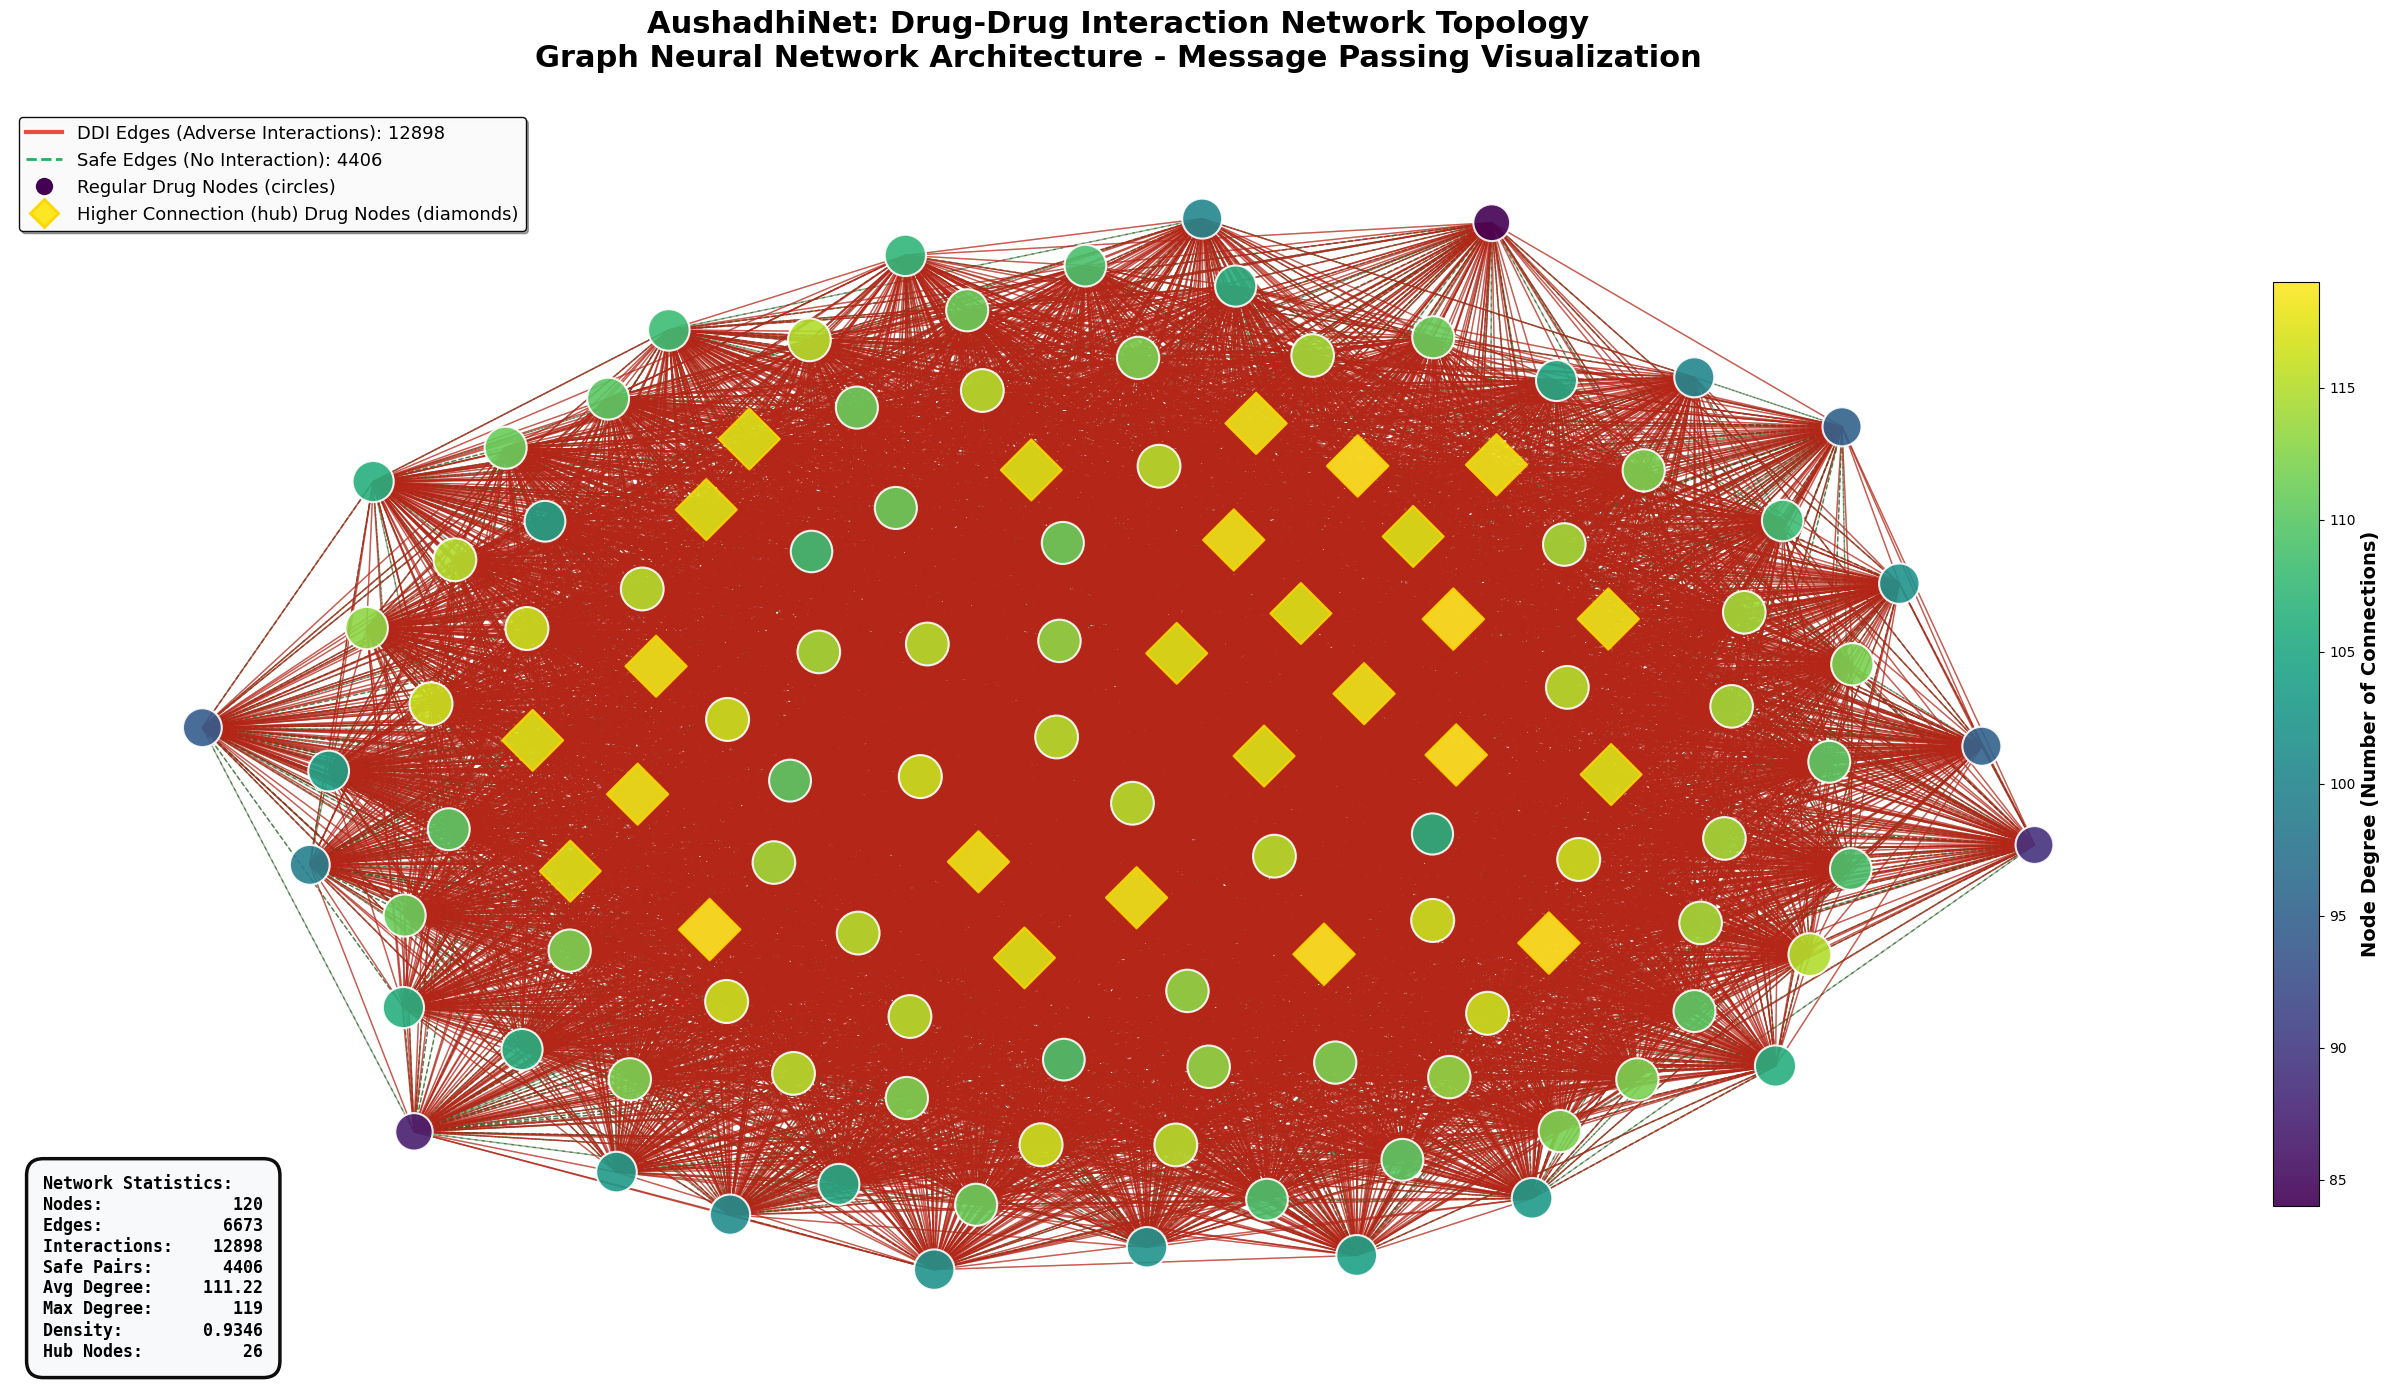

In [ ]:
# Visualizes the drug interaction network structure showing nodes (drugs) and edges (interactions)


def visualize_drug_interaction_graph(graph, num_nodes=150, seed=42):
    """
    Create a publication-quality visualization of the drug interaction network.
    
    Parameters:
    - graph: The graph dictionary containing edge_index, drug_map, y_binary
    - num_nodes: Number of nodes to display (will include their connections)
    - seed: Random seed for reproducible layout
    
    Returns:
    - Saves high-resolution figure to images/ directory
    """
    print("● Generating Graph Network Visualization...")
    
    # Extract graph data
    edge_index = graph['edge_index'].cpu().numpy()
    y_binary = graph['y_binary'].cpu().numpy()
    total_nodes = graph['x_v1'].shape[0]
    
    print(f"  - Total nodes in graph: {total_nodes}")
    print(f"  - Total edges in graph: {edge_index.shape[1]}")
    
    # Calculate degree for each node
    degree_count = {}
    for i in range(edge_index.shape[1]):
        src, dst = int(edge_index[0, i]), int(edge_index[1, i])
        degree_count[src] = degree_count.get(src, 0) + 1
        degree_count[dst] = degree_count.get(dst, 0) + 1
    
    # Select top nodes by degree (hub nodes)
    sorted_nodes = sorted(degree_count.items(), key=lambda x: x[1], reverse=True)
    selected_nodes = [node for node, deg in sorted_nodes[:num_nodes]]
    selected_nodes_set = set(selected_nodes)
    
    print(f"  - Selected {len(selected_nodes)} high-degree nodes")
    
    # Create NetworkX graph and add all edges between selected nodes
    G = nx.Graph()
    G.add_nodes_from(selected_nodes)
    
    pos_edges = []
    neg_edges = []
    
    # Add edges where BOTH endpoints are in selected nodes
    for i in range(edge_index.shape[1]):
        src, dst = int(edge_index[0, i]), int(edge_index[1, i])
        
        if src in selected_nodes_set and dst in selected_nodes_set and src != dst:
            edge = (src, dst)
            if y_binary[i] == 1:
                pos_edges.append(edge)
            else:
                neg_edges.append(edge)
    
    # Remove duplicates (since graph is bidirectional)
    pos_edges = list(set(pos_edges))
    neg_edges = list(set(neg_edges))
    
    print(f"  - Found {len(pos_edges)} interaction edges")
    print(f"  - Found {len(neg_edges)} safe edges")
    
    # Add edges to graph
    G.add_edges_from(pos_edges)
    G.add_edges_from(neg_edges)
    
    # Remove isolated nodes
    isolated = list(nx.isolates(G))
    G.remove_nodes_from(isolated)
    print(f"  - Removed {len(isolated)} isolated nodes")
    print(f"  - Final graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    if G.number_of_edges() == 0:
        print("⚠ Warning: No edges found! Using alternative sampling strategy...")
        # Fallback: sample random connected subgraph
        G = nx.Graph()
        sample_edges = np.random.choice(edge_index.shape[1], min(1000, edge_index.shape[1]), replace=False)
        for idx in sample_edges:
            src, dst = int(edge_index[0, idx]), int(edge_index[1, idx])
            if src != dst:
                G.add_edge(src, dst, interaction=int(y_binary[idx]))
        
        # Get largest connected component
        if G.number_of_nodes() > 0:
            largest_cc = max(nx.connected_components(G), key=len)
            G = G.subgraph(largest_cc).copy()
            
            # Separate edges by type
            pos_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('interaction', 0) == 1]
            neg_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('interaction', 0) == 0]
    
    # Calculate node properties
    node_degrees = dict(G.degree())
    
    # Smaller node sizes
    node_sizes = [20 + node_degrees.get(node, 0) * 8 for node in G.nodes()]
    
    # Create wider figure
    fig, ax = plt.subplots(figsize=(24, 14), facecolor='white')
    
    # Layout - use spring layout for better separation
    print("  - Computing graph layout...")
    pos = nx.spring_layout(G, k=2.0, iterations=60, seed=seed)
    
    # Draw SAFE edges first (green, thin, dashed)
    if len(neg_edges) > 0:
        nx.draw_networkx_edges(
            G, pos,
            edgelist=neg_edges,
            width=1.0,
            alpha=0.5,
            edge_color='#175212',  # Green for safe
            style='dashed',
            ax=ax
        )
    
    # Draw INTERACTION edges (red, thicker, solid)
    if len(pos_edges) > 0:
        nx.draw_networkx_edges(
            G, pos,
            edgelist=pos_edges,
            width=1.0,
            alpha=0.5,
            edge_color='#b52618',  # Red for interactions
            ax=ax
        )
    
    # Separate nodes by degree for different shapes
    high_degree_nodes = [n for n in G.nodes() if node_degrees.get(n, 0) > np.percentile(list(node_degrees.values()), 75)]
    low_degree_nodes = [n for n in G.nodes() if n not in high_degree_nodes]
    
    # Draw low-degree nodes (circles)
    if len(low_degree_nodes) > 0:
        low_colors = [node_degrees.get(node, 0) for node in low_degree_nodes]
        low_sizes = [30 + node_degrees.get(node, 0) * 8 for node in low_degree_nodes]
        low_pos = {k: v for k, v in pos.items() if k in low_degree_nodes}
        
        nx.draw_networkx_nodes(
            G, low_pos,
            nodelist=low_degree_nodes,
            node_size=low_sizes,
            node_color=low_colors,
            node_shape='o',  # Circle
            cmap=plt.cm.viridis,
            alpha=0.9,
            edgecolors='white',
            linewidths=1.5,
            vmin=min(node_degrees.values()),
            vmax=max(node_degrees.values()),
            ax=ax
        )
    
    # Draw high-degree nodes (diamonds) - hub drugs
    if len(high_degree_nodes) > 0:
        high_colors = [node_degrees.get(node, 0) for node in high_degree_nodes]
        high_sizes = [30 + node_degrees.get(node, 0) * 8 for node in high_degree_nodes]
        high_pos = {k: v for k, v in pos.items() if k in high_degree_nodes}
        
        nodes_high = nx.draw_networkx_nodes(
            G, high_pos,
            nodelist=high_degree_nodes,
            node_size=high_sizes,
            node_color=high_colors,
            node_shape='D',  # Diamond for hub nodes
            cmap=plt.cm.viridis,
            alpha=0.9,
            edgecolors='gold',
            linewidths=1.5,
            vmin=min(node_degrees.values()),
            vmax=max(node_degrees.values()),
            ax=ax
        )
        
        # Colorbar
        cbar = plt.colorbar(nodes_high, ax=ax, fraction=0.02, pad=0.02)
        cbar.set_label('Node Degree (Number of Connections)', fontsize=14, fontweight='bold')
    
    # Title
    ax.set_title(
        'AushadhiNet: Drug-Drug Interaction Network Topology\n'
        f'Graph Neural Network Architecture - Message Passing Visualization',
        fontsize=22,
        fontweight='bold',
        pad=30
    )
    
    # Enhanced Legend
    legend_elements = [
        plt.Line2D([0], [0], color='#E74C3C', linewidth=3, 
                   label=f'DDI Edges (Adverse Interactions): {len(pos_edges)}'),
        plt.Line2D([0], [0], color='#27AE60', linewidth=2, linestyle='--', 
                   label=f'Safe Edges (No Interaction): {len(neg_edges)}'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#440154', 
                   markersize=14, markeredgecolor='white', markeredgewidth=1.5,
                   label='Regular Drug Nodes (circles)', linestyle='None'),
        plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#FDE724', 
                   markersize=14, markeredgecolor='gold', markeredgewidth=2,
                   label='Higher Connection (hub) Drug Nodes (diamonds)', linestyle='None')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=13, 
              framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    
    # Statistics box
    avg_degree = np.mean(list(node_degrees.values())) if node_degrees else 0
    max_degree = max(node_degrees.values()) if node_degrees else 0
    density = nx.density(G)
    
    stats_text = (
        f"Network Statistics:\n"
        f"Nodes:          {G.number_of_nodes():>6}\n"
        f"Edges:          {G.number_of_edges():>6}\n"
        f"Interactions:   {len(pos_edges):>6}\n"
        f"Safe Pairs:     {len(neg_edges):>6}\n"
        f"Avg Degree:     {avg_degree:>6.2f}\n"
        f"Max Degree:     {max_degree:>6}\n"
        f"Density:        {density:>6.4f}\n"
        f"Hub Nodes:      {len(high_degree_nodes):>6}"
    )
    
    props = dict(boxstyle='round,pad=1.0', facecolor='#F8F9FA', 
                 edgecolor='black', linewidth=2.5, alpha=0.95)
    ax.text(0.015, 0.015, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='bottom', bbox=props, family='monospace',
            fontweight='bold')
    
    ax.axis('off')
    plt.tight_layout()
    
    # Save
    output_path = f"images/AushadhiNet_graph_topology_{TIMESTAMP}.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n✓ Graph visualization saved to: {output_path}")
    
    # Print final statistics
    print(f"\n● Final Network Statistics:")
    print(f"  - Nodes (Drugs): {G.number_of_nodes()}")
    print(f"  - Edges (Total): {G.number_of_edges()}")
    print(f"  - Positive Edges (Interactions): {len(pos_edges)}")
    print(f"  - Negative Edges (Safe): {len(neg_edges)}")
    print(f"  - Hub Nodes (High Degree): {len(high_degree_nodes)}")
    print(f"  - Average Degree: {avg_degree:.2f}")
    print(f"  - Network Density: {density:.4f}")
    
    plt.show()
    plt.close()
    
    return G, pos


# Generate the visualization
G, pos = visualize_drug_interaction_graph(
    graph, 
    num_nodes=120,  # Adjust for more/fewer nodes
    seed=42
)


### 15. Comprehensive Test Set Evaluation
_Multi-Metric Performance Assessment and Confusion Matrix Analysis._ A evaluation protocol on the held-out test set, computing both binary classification metrics (accuracy, F1, precision, recall, ROC-AUC) and interaction type classification performance. The function processes test edges in batches to manage memory, accumulating predictions and ground truth labels for comprehensive analysis.

The confusion matrix decomposition (True Positives, False Positives, True Negatives, False Negatives) provides critical insights into model failure modes. In the DDI context, False Negatives (missed interactions) represent the most dangerous error type, potentially leading to adverse drug events in clinical practice. The per-type accuracy analysis identifies which interaction mechanisms the model predicts most reliably, informing targeted model improvements.

Accuracy: $\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$

Precision: $\text{Precision} = \frac{TP}{TP + FP}$

Recall: $\text{Recall} = \frac{TP}{TP + FN}$

F1 Score: $F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$


In [15]:
def training_evaluation(model, graph, batch_size=512):
    """
    Complete test set evaluation with:
    - Binary classification metrics
    - Type classification metrics
    - Confusion matrix
    - Per-class performance
    """
    print("COMPREHENSIVE TEST SET EVALUATION")
    print("—"*33, "\n")
    
    model.eval()
    test_edges = graph['edge_index'][:, graph['test_mask']]
    test_labels_bin = graph['y_binary'][graph['test_mask']]
    test_labels_type = graph['y_type'][graph['test_mask']]
    
    test_loader = DataLoader(
        TensorDataset(test_edges.t(), 
                     torch.stack([test_labels_bin, test_labels_type], dim=1)),
        batch_size=batch_size, shuffle=False
    )
    
    full_adj = graph['edge_index'].to(DEVICE)
    x_v1, x_v2, x_v3 = graph['x_v1'].to(DEVICE), graph['x_v2'].to(DEVICE), graph['x_v3'].to(DEVICE)
    
    all_preds_bin, all_probs_bin, all_trues_bin = [], [], []
    all_preds_type, all_trues_type = [], []
    
    with torch.no_grad():
        with autocast(DEVICE_TYPE):
            node_emb = model.get_node_embeddings(x_v1, x_v2, x_v3, full_adj)
        
        for batch_edges, batch_labels in test_loader:
            batch_edges = batch_edges.t().to(DEVICE)
            p_bin, p_type = model.forward_edges_from_emb(node_emb, batch_edges)
            
            # Binary predictions
            probs = torch.softmax(p_bin, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(p_bin, dim=1).cpu().numpy()
            all_preds_bin.extend(preds)
            all_probs_bin.extend(probs)
            all_trues_bin.extend(batch_labels[:, 0].numpy())
            
            # Type predictions (only for positive samples)
            type_preds = torch.argmax(p_type, dim=1).cpu().numpy()
            all_preds_type.extend(type_preds)
            all_trues_type.extend(batch_labels[:, 1].numpy())
    
    # Convert to arrays
    y_true_bin = np.array(all_trues_bin)
    y_pred_bin = np.array(all_preds_bin)
    y_prob_bin = np.array(all_probs_bin)
    y_true_type = np.array(all_trues_type)
    y_pred_type = np.array(all_preds_type)
    
    # 1. BINARY CLASSIFICATION
    print("1. BINARY CLASSIFICATION (Interaction: Yes/No)")
    print(f"{'-'*46}")
    
    acc = accuracy_score(y_true_bin, y_pred_bin)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    
    try:
        roc_auc = roc_auc_score(y_true_bin, y_prob_bin)
    except:
        roc_auc = float('nan')
    
    print(f"• Accuracy:      {acc:.4f}  {'(✓)' if acc >= 0.90 else '(Target: 0.90)'}")
    print(f"• F1 Score:      {f1:.4f}  {'(✓)' if f1 >= 0.85 else ' (Target: 0.85)'}")
    print(f"• Precision:     {prec:.4f}")
    print(f"• Recall:        {rec:.4f}  {'(✓)' if rec >= 0.85 else ' (Important: catch interactions!)'}")
    print(f"• ROC-AUC:       {roc_auc:.4f}")
    
    # Confusion Matrix

    cm = confusion_matrix(y_true_bin, y_pred_bin)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n1.2 CONFUSION MATRIX:")
    print(f"-"*61)
    print(f"| {' '*16}| Predicted: No Int | Predicted: Interact |")
    print(f"| Actual No Int   | {tn:6d}{' '*12}|{fp:6d} {' '*14}|")
    print(f"| Actual Interact | {fn:6d}{' '*12}|{tp:6d} {' '*14}|")
    print(f"-"*61)
    print(f"• True Positives:  {tp:6d}  (Correctly detected interactions)")
    print(f"• False Positives: {fp:6d}  (False alarms - Incorrectly predicted as safe)")
    print(f"• False Negatives: {fn:6d}  (⚠ CRITICAL: Missed interactions!)")
    print(f"• True Negatives:  {tn:6d}  (Correctly identified safe)")
    
    # 2. INTERACTION TYPES CLASSIFICATION
    print("\n\n2. TYPE CLASSIFICATION (Which interaction type?)")
    print(f"{'-'*48}")
    
    # Filter to only positive samples (where type is meaningful)
    pos_mask = y_true_bin == 1
    if pos_mask.sum() > 0:
        y_true_type_pos = y_true_type[pos_mask]
        y_pred_type_pos = y_pred_type[pos_mask]
        
        type_acc = accuracy_score(y_true_type_pos, y_pred_type_pos)
        type_f1 = f1_score(y_true_type_pos, y_pred_type_pos, average='weighted', zero_division=0)
        
        print(f"• 'Type' Accuracy: {type_acc:.4f}")
        print(f"• 'Type' F1 Score: {type_f1:.4f}")
        print(f"• Total 'Types': {len(np.unique(y_true_type_pos))} unique types in test set")
        
        # Top 5 most common types
        from collections import Counter
        type_counts = Counter(y_true_type_pos)
        print(f"\n• Top 5 Most Common Interaction Types:")
        for type_id, count in type_counts.most_common(5):
            type_name = graph['encoder'].inverse_transform([type_id])[0]
            accuracy = (y_pred_type_pos[y_true_type_pos == type_id] == type_id).mean()
            print(f"  - Type {type_name}: {count:4d} samples, {accuracy:.2%} accuracy")
    
    return {
        'binary': {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec, 'roc_auc': roc_auc},
        'type': {'accuracy': type_acc, 'f1': type_f1} if pos_mask.sum() > 0 else {},
        'confusion_matrix': {'true_positve': tp, 'false_positive': fp, 'true_negtive': tn, 'false_negative': fn},
    }

# Run comprehensive evaluation
test_results = training_evaluation(trained_model, graph)

COMPREHENSIVE TEST SET EVALUATION
————————————————————————————————— 

1. BINARY CLASSIFICATION (Interaction: Yes/No)
----------------------------------------------
• Accuracy:      0.6270  (Target: 0.90)
• F1 Score:      0.7064   (Target: 0.85)
• Precision:     0.5825
• Recall:        0.8973  (✓)
• ROC-AUC:       0.7228

1.2 CONFUSION MATRIX:
-------------------------------------------------------------
|                 | Predicted: No Int | Predicted: Interact |
| Actual No Int   |  20531            | 37012               |
| Actual Interact |   5911            | 51631               |
-------------------------------------------------------------
• True Positives:   51631  (Correctly detected interactions)
• False Positives:  37012  (False alarms - Incorrectly predicted as safe)
• False Negatives:   5911  (⚠ CRITICAL: Missed interactions!)
• True Negatives:   20531  (Correctly identified safe)


2. TYPE CLASSIFICATION (Which interaction type?)
------------------------------------------

#### 16. Finding Best Threshold for Prediction
Performs a grid search over classification thresholds to identify the operating point that maximizes accuracy while maintaining acceptable precision-recall balance. The default threshold of 0.5 assumes equal misclassification costs, but in clinical applications, the cost of missing an interaction (False Negative) typically exceeds the cost of a false alarm (False Positive).

The function evaluates thresholds from 0.3 to 0.75 in 0.05 increments, computing accuracy, F1, precision, and recall at each point. The tabular output enables informed threshold selection based on application-specific requirements.

In [16]:
def find_best_threshold(model, graph, device):
    """Find threshold that balances precision/recall for target accuracy."""
    model.eval()
    val_edges = graph['edge_index'][:, graph['val_mask']]
    val_labels_bin = graph['y_binary'][graph['val_mask']]

    val_loader = DataLoader(
        TensorDataset(val_edges.t(), val_labels_bin.unsqueeze(1)),
        batch_size=1024, shuffle=False
    )

    all_probs, all_trues = [], []
    with torch.no_grad():
        with autocast(device.type):
            node_emb = model.get_node_embeddings(
                graph['x_v1'].to(device), graph['x_v2'].to(device),
                graph['x_v3'].to(device), graph['edge_index'].to(device)
            )
        for batch_edges, batch_y in val_loader:
            p_bin, _ = model.forward_edges_from_emb(node_emb, batch_edges.t().to(device))
            probs = torch.softmax(p_bin, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_trues.extend(batch_y.squeeze().numpy())

    y_true = np.array(all_trues)
    y_prob = np.array(all_probs)

    print(f"\n{'—'*55}")
    print(f"{'Thresh':<8} | {'Acc':<8} | {'F1':<8} | {'Prec':<8} | {'Rec':<8}")
    print(f"{'—'*55}")

    best_acc, best_thresh = 0, 0.5
    for thresh in np.arange(0.3, 0.75, 0.05):
        preds = (y_prob >= thresh).astype(int)
        acc  = accuracy_score(y_true, preds)
        f1   = f1_score(y_true, preds, zero_division=0)
        prec = precision_score(y_true, preds, zero_division=0)
        rec  = recall_score(y_true, preds, zero_division=0)
        marker = " ← best acc" if acc > best_acc else ""
        print(f"  {thresh:.2f}   | {acc:.4f}  | {f1:.4f}  | {prec:.4f}  | {rec:.4f}{marker}")
        if acc > best_acc:
            best_acc = acc
            best_thresh = thresh

    print(f"{'—'*55}")
    print(f"Best threshold: {best_thresh:.2f} → Accuracy: {best_acc:.4f}")
    return best_thresh

# calling function
BEST_THRESHOLD = find_best_threshold(model, graph, DEVICE)
print(f"Best threshold to use for predictions: {BEST_THRESHOLD:.2f}")


———————————————————————————————————————————————————————
Thresh   | Acc      | F1       | Prec     | Rec     
———————————————————————————————————————————————————————
  0.30   | 0.5034  | 0.6682  | 0.5017  | 1.0000 ← best acc
  0.35   | 0.5090  | 0.6706  | 0.5046  | 0.9997 ← best acc
  0.40   | 0.5225  | 0.6763  | 0.5115  | 0.9979 ← best acc
  0.45   | 0.5561  | 0.6890  | 0.5302  | 0.9834 ← best acc
  0.50   | 0.6243  | 0.7045  | 0.5806  | 0.8957 ← best acc
  0.55   | 0.6543  | 0.6335  | 0.6740  | 0.5976 ← best acc
  0.60   | 0.5640  | 0.2870  | 0.7872  | 0.1755
  0.65   | 0.5081  | 0.0374  | 0.8696  | 0.0191
  0.70   | 0.5004  | 0.0018  | 0.8814  | 0.0009
———————————————————————————————————————————————————————
Best threshold: 0.55 → Accuracy: 0.6543
Best threshold to use for predictions: 0.55


### 17. Saving Model Logs and Metadata
A  comprehensive metadata record capturing all aspects of the training experiment. And 

#### 17.2 Graph Data Serialization for Inference
_Production Deployment Artifact Generation_. Serializes the complete graph structure and auxiliary data required for inference, including node features (all three views), edge topology, drug-to-index mapping, interaction type encoder, and metadata. The saved `.pt` file serves as a self-contained inference package, enabling model deployment without access to the original training data or preprocessing pipeline.

In [17]:
# Prepare log entry
current_log = {
    "training_data": TIMESTAMP,
    "total_training duration": training_history["training_duration"],
    "training_configuration": CONFIG,
    "final_training_metadata": {
        "training_loss": round(training_history["train_loss"][-1], 3),
        "validation_accuracy": round(training_history["val_acc"][-1], 3),
        "validation_f1-Score": round(training_history["val_f1"][-1], 3),
        "validation_precision": round(training_history["val_precision"][-1], 3),
        "validation_recall": round(training_history["val_recall"][-1], 3),
    },    
    "model_evaluation_result": {
        "binary_classification": {
            "accuracy":  round(test_results["binary"]["accuracy"],  3),
            "f1_Score":  round(test_results["binary"]["f1"],        3),
            "precision": round(test_results["binary"]["precision"], 3),
            "recall":    round(test_results["binary"]["recall"],    3),
            "roc_auc":   round(test_results["binary"]["roc_auc"],   3),
        },
        "Type Classification": {
            "accuracy": round(test_results["type"]["accuracy"], 3),
            "f1_score": round(test_results["type"]["f1"],       3),
        },
        "true_positve": int(test_results['confusion_matrix']['true_positve']),
        "false_positive": int(test_results['confusion_matrix']['false_positive']),
        "true_negtive": int(test_results['confusion_matrix']['true_negtive']),
        "false_negative": int(test_results['confusion_matrix']['false_negative']),
    },
    "best_threshold": f"{BEST_THRESHOLD:.3f}",
    "validation_accuracy_history": training_history["val_acc"],
    "training_loss_history": training_history["train_loss"],
}

log_file = f"{MODEL_METADATA_PATH}.json"
os.makedirs(os.path.dirname(log_file), exist_ok=True)

#  Load existing logs if file exists
if os.path.exists(log_file):
    with open(log_file, "r") as f:
        try:
            logs_list = json.load(f)
            if not isinstance(logs_list, list):
                logs_list = []
        except json.JSONDecodeError:
            logs_list = []
else:
    logs_list = []

#  Append new log
logs_list.append(current_log)

# 6Save file
with open(log_file, "w") as f:
    json.dump(logs_list, f, indent=4)
print(f"(✓) Log successfully saved to {log_file}!\n")

# SAVING GRAPH DATA
# =================
inference_data = {
    'x_v1': graph['x_v1'].cpu(),
    'x_v2': graph['x_v2'].cpu(),
    'x_v3': graph['x_v3'].cpu(),
    'edge_index': graph['edge_index'].cpu(),
    'drug_map': graph['drug_map'],
    'n_types': graph['n_types'],
    'encoder': graph['encoder']
}
torch.save(inference_data, f'models/graph_data_{TIMESTAMP}.pt')
print(f"(✓) Saved to: models/graph_data_{TIMESTAMP}.pt")

(✓) Log successfully saved to models/AushadiNet_GATv2-metadata_26_Feb_13-54.json!

(✓) Saved to: models/graph_data_26_Feb_13-54.pt


### 18. Inference Function Implementation: Model Prediction Testing
A complete inference pipeline for predicting interactions between arbitrary drug pairs. The function performs several critical operations: (1) validates drug IDs exist in the knowledge graph; (2) extracts a 1-hop subgraph around the query pair using k_hop_subgraph(); (3) computes node embeddings via the trained GNN; (4) predicts interaction probability and type; (5) formats results with clinical interpretations.

> Time to test the real world drugs prescription

> **NOTE:** For production level prediction experienc, please visit this URL and perform prediction with function application UI

In [ ]:
# A complete inference pipeline for predicting interactions between multiple drug combinations
from itertools import combinations

with open(DDI_TYPE_MAP, 'r') as f:
    ddi_type_map = json.load(f)

def predict_ddi_multi(model, graph, threshold=0.5):
    """
    Enhanced multi-drug interaction prediction:
    - Accepts 2-4 drugs as input
    - Validates no duplicate drugs
    - Checks all pairwise combinations
    - Returns interaction report
    
    Parameters:
    - model: Trained GATv2NN model
    - graph: Graph data dictionary
    - threshold: Classification threshold (default 0.5)
    
    Returns:
    - Dictionary with all pairwise predictions
    """
    
    # Step 1: Get number of drugs
    drugs_num = int(input("\nEnter total number of drugs (2 to 4): "))
    if drugs_num < 2 or drugs_num > 4:
        raise ValueError(f"Invalid number of drugs: {drugs_num}. Must be between 2 and 4.")
    
    # Step 2: Collect drug IDs with validation
    drug_list = []
    print(f"\nPlease enter {drugs_num} UNIQUE drug IDs (e.g., DB00001):")
    
    for idx in range(drugs_num):
        drug_id = input(f"Drug {idx+1}: ").strip().upper()
        
        # Check if empty
        if not drug_id:
            raise ValueError("Drug ID cannot be empty.")
        
        # Check for duplicates
        if drug_id in drug_list:
            raise ValueError(f"Duplicate drug detected: '{drug_id}' already entered. Drugs must be unique.")
        
        # Check if exists in database
        if drug_id not in graph['drug_map']:
            raise ValueError(f"Drug ID '{drug_id}' not found in database.")
        
        drug_list.append(drug_id)
    
    print(f"\n✓ Received {len(drug_list)} unique drugs: {drug_list}")
    
    # Step 3: Generate all pairwise combinations
    drug_pairs = list(combinations(drug_list, 2))
    
    # Step 4: Predict each pair
    model.eval()
    all_results = []
    
    for pair_idx, (drug_a_id, drug_b_id) in enumerate(drug_pairs, 1):
        print(f"\n[Pair {pair_idx}/{len(drug_pairs)}] Analyzing: {drug_a_id} + {drug_b_id}")
        print("-" * 60)
        
        # Get node indices
        u = graph['drug_map'][drug_a_id]
        v = graph['drug_map'][drug_b_id]
        
        query_node_indices = torch.tensor([u, v], dtype=torch.long)
        
        # Extract 1-hop subgraph
        subset, edge_index, mapping, edge_mask = k_hop_subgraph(
            node_idx=query_node_indices, 
            num_hops=1, 
            edge_index=graph['edge_index'], 
            relabel_nodes=True
        )
        
        subgraph_u = mapping[0]
        subgraph_v = mapping[1]
        query_edge = torch.tensor([[subgraph_u], [subgraph_v]], device=DEVICE)
        
        # Get features
        x_v1 = graph['x_v1'][subset].to(DEVICE)
        x_v2 = graph['x_v2'][subset].to(DEVICE)
        x_v3 = graph['x_v3'][subset].to(DEVICE)
        edge_index = edge_index.to(DEVICE)
        
        with torch.no_grad():
            # Get predictions
            logits_bin, logits_type = model(x_v1, x_v2, x_v3, edge_index, query_edge)
            
            # Binary prediction
            probs_bin = torch.softmax(logits_bin, dim=1)[0]
            prob_interaction = probs_bin[1].item()
            binary_pred = 1 if prob_interaction > threshold else 0
            
            # Type prediction
            probs_type = torch.softmax(logits_type, dim=1)[0]
            type_idx = torch.argmax(logits_type, dim=1).item()
            type_prob = probs_type[type_idx].item()
        
        interaction_effect = ddi_type_map.get(str(type_idx), "Unknown interaction type")
        
        # Print results for this pair
        if binary_pred == 1:
            print(f"⚠ INTERACTION DETECTED (Not Safe)")
            print(f"  • Interaction Probability:    {prob_interaction:.2%}")
            print(f"  • Interaction Type:           {type_idx}")
            print(f"  • Interaction Effect:         {interaction_effect}")
            print(f"  • Type Confidence:            {type_prob:.2%}")
        else:
            print(f"✓ NO INTERACTION (Safe)")
            print(f"  • Safety Probability:         {(1-prob_interaction):.2%}")
        
        # Store results
        result = {
            'pair_number': pair_idx,
            'drug_a': drug_a_id,
            'drug_b': drug_b_id,
            'binary_prediction': binary_pred,
            'interaction_probability': prob_interaction,
            'interaction_type': type_idx,
            'interaction_effect': interaction_effect,
            'type_probability': type_prob,
            'safe': binary_pred == 0
        }
        all_results.append(result)
    
    interactions_found = sum(1 for r in all_results if r['binary_prediction'] == 1)
    safe_pairs = len(all_results) - interactions_found
    
    if interactions_found > 0:
        print(f"\n⚠ WARNING: {interactions_found} interaction(s) detected!")
        print("  Interacting Pairs:")
        for r in all_results:
            if r['binary_prediction'] == 1:
                print(f"    • {r['drug_a']} + {r['drug_b']}: {r['interaction_effect']} ({r['interaction_probability']:.1%})")
    else:
        print("\n✓ All drug combinations appear safe!")
    
    print("\n" + "="*60)
    
    return {
        'drugs': drug_list,
        'total_pairs': len(all_results),
        'interactions_found': interactions_found,
        'safe_pairs': safe_pairs,
        'detailed_results': all_results
    }

# Run the interactive prediction
results = predict_ddi_multi(trained_model, graph, threshold=BEST_THRESHOLD)



Please enter 2 UNIQUE drug IDs (e.g., DB00001):


ValueError: Drug ID 'DB00342' not found in database.

### Some clinically tested and drug bank verified DDI example to try

| Pair | Drug A (Name & ID) | Drug B (Name & ID) | Expected Risk | Clinical Logic |
| :--- | :--- | :--- | :--- | :--- |
| 1 | **Empagliflozin** (DB09038) | **Atorvastatin** (DB01076) | (✓) **SAFE NO INTERACTION** | - |
| 2 | **Sertraline** (DB01104) | **Carvedilol** (DB01136) | ⚠ **INTERACT** (moderate) | The serum concentration of Carvedilol can be increased when it is combined with Sertraline.|
| 3 | **Warfarin** (DB00682) | **Aspirin** (DB00945) | ⚠ **INTERACT** (high-moderate) | Classic interaction; both thin the blood, significantly increasing bleeding risk. |
| 4 | **Amoxicillin** (DB01060) | **Clavulanic Acid** (DB00766) | (✓) **SAFE NO INTERACTION** | These are frequently sold as a single combination pill (Augmentin). |
| 4 | **Ibuprofen** (DB01050) | **Naproxen** (DB00788) | ⚠ **INTERACT** | ibuprofen and naproxen both increase anticoagulation. Risk of side effects in the gastrointestinal tract such as inflammation, bleeding, ulceration, and rarely, perforation |


### 1. Validation Accuracy
**Definition:** The percentage of total predictions that were correct (both True Positives and True Negatives).

$$
\text{Accuracy} = \frac{\text{True Positives} + \text{True Negatives}}{\text{Total Predictions}}
$$

* **The Trap:** Accuracy is deceptive if your classes are imbalanced. If 95% of your drug pairs do **not** interact, a model that simply predicts "No Interaction" every time will have **95% accuracy** but is effectively useless because it fails to catch any actual interactions.

### 2. Validation Precision
**Definition:** Of all the instances the model *claimed* were positive, how many were actually positive?

$$
\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}
$$

* **Focus:** It measures the "purity" of your positive predictions. High precision means that when your model says "These two drugs will interact," you can be very confident it is right. It minimizes "False Alarms."

### 3. F1-Score: The Balanced Metric
**Definition:** The harmonic mean of **Precision** and **Recall**.

$$
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

* **Recall (Sensitivity):** Of all the actual interactions that exist in the real world, how many did the model find?
* **Why use F1?** F1-Score penalizes extreme values. A model with 100% Precision but 1% Recall (it only found one interaction but was right about it) will have a terrible F1-score. F1 requires both Precision and Recall to be healthy to give a high score.

### 4. ROC-AUC (Area Under the Receiver Operating Characteristic Curve)
**Definition:** The probability that a random positive example is ranked higher than a random negative example.

Mathematically, it is the integral (area) under the plot of **True Positive Rate (TPR)** vs. **False Positive Rate (FPR)** at various threshold settings $T$:

$$
\text{AUC} = \int_{0}^{1} \text{TPR}(\text{FPR}^{-1}(x)) \, dx
$$

Where:
* $TPR(T) = \frac{TP}{TP + FN}$ (Recall)
* $FPR(T) = \frac{FP}{FP + TN}$

**Why use it?** unlike Accuracy, ROC-AUC is threshold-independent.
* **1.0:** Perfect model (Correctly distinguishes all Positive vs Negative).
* **0.5:** Random guessing (No discrimination capacity).

### 5. Gradient Metrics (The "Training Landscape")

To understand how the model learns, we track how it moves down the "Loss Landscape" (the 3D mountain graph).

#### A. Gradient Descent Formula
The standard rule for updating a weight parameter $\theta$ (e.g., a connection in your GATv2 layers) using the gradient of the Loss function $J(\theta)$ is:

$$
\theta_{new} = \theta_{old} - \eta \cdot \nabla J(\theta)
$$

* $\eta$ (Eta): Learning rate (step size).
* $\nabla J(\theta)$: The gradient (slope) of the loss with respect to the weights.

#### B. Gradient Accumulation Formula
Since we cannot fit the full batch $B$ into memory, we split it into mini-batches $b$. We accumulate the gradients over $N$ steps before updating.

The effective gradient used for the update is the sum of gradients from small batches:

$$
\nabla_{\text{total}} = \sum_{i=1}^{N} \frac{\nabla J_i(\theta)}{N}
$$

* **Why divide by N?** We average the loss (or gradients) to ensure the magnitude of the update doesn't explode just because we added more batches.

#### C. Gradient Norm (The Visual Metric)
This is what we plot to visualize the "Steepness" of the mountain slope. It is the Euclidean norm ($L2$ norm) of the entire gradient vector $g$:

$$
\|g\|_2 = \sqrt{\sum_{i} g_i^2}
$$

* **High Norm:** The slope is very steep. The model is learning rapidly, or the training is unstable/exploding.
* **Low Norm:** The slope is flat. The model has likely converged to a solution (bottom of the valley) or is stuck on a plateau.